### **Experiments for N-dim convex optimization problem**

We have trained more adaptive learning rate (LR) models for Gradient Descent models to be used in higher dimensions: **[5, 10, 100, 800]**

800 is the maximum value because we need the measurement to align with the number of parameters in the MNIST problem

In [2]:
import gymnasium as gym
import src.gymnasium_envs.convex_optimization_env
import src.utils.exps_utils as exps

seed = 42
max_iterations = 10000

env_id = "convex_optimization_env/ConvexOptimization-v1"

available_dims = [2, 5, 10, 100]

base_env_kwargs = {
    
}

### 1. Convergence on [2, 5, 10, 100] vs. ADAM and GD 

Let's build convergence graphs for models trained on a specific dimension

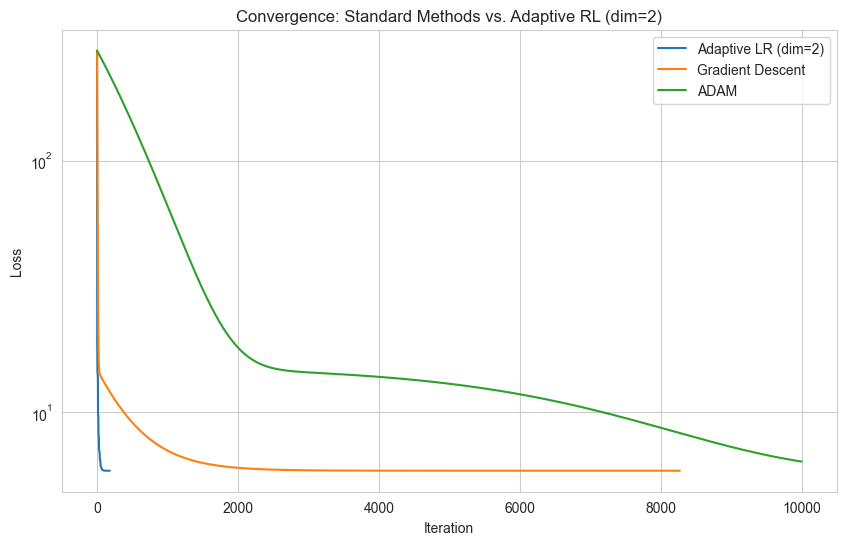

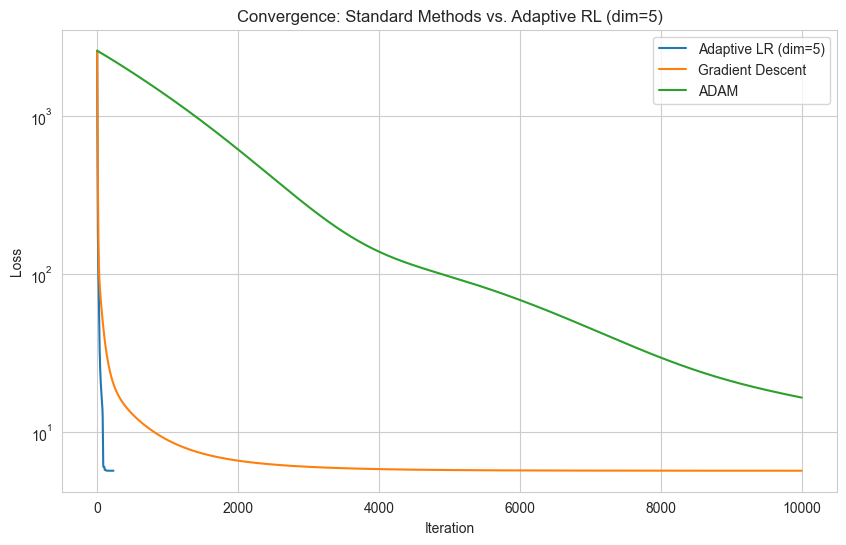

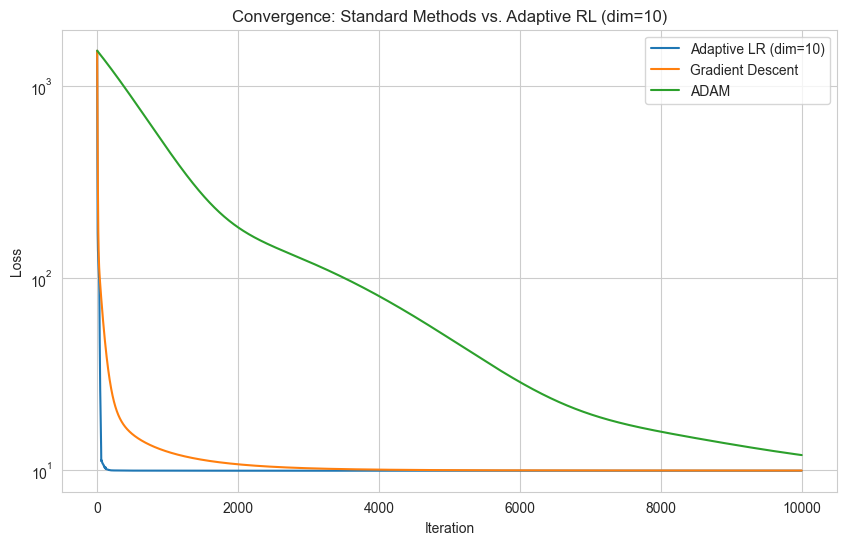

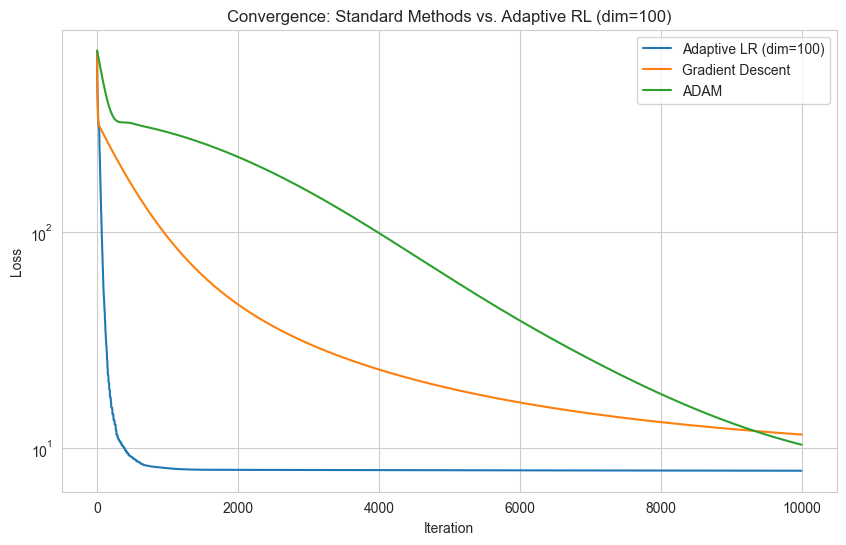

In [2]:
for dim in available_dims:
    stats = f"../models/{dim}d_convex_vec_normalize.pkl"
    model = f"../models/{dim}d_convex"
    
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result_rl, x0, function = exps.optimize_exp_rl(method=f"Adaptive LR (dim={dim})", env_config=env_config, model_dir=model_dir)
    result_gdesc = exps.optimize_exp_standart(method="GD", x0=x0, function=function, env_config=env_config)
    result_adam = exps.optimize_exp_standart(method="ADAM", x0=x0, function=function, env_config=env_config)
    
    result = result_rl | result_gdesc | result_adam

    exps.plot_converging_comparasion(result, dim, title=f"Convergence: Standard Methods vs. Adaptive RL (dim={dim})")
    

### 2. Distribution of the number of iterations on [2, 5, 10, 100] vs. ADAM and GD

Let's build tables with statistical characteristics of the iteration distribution.

In [3]:
sample_count = 10

for dim in available_dims:
    print(f"Distribution of iterations number on {dim}-dim convex problem")

    stats = f"../models/{dim}d_convex_vec_normalize.pkl"
    model = f"../models/{dim}d_convex"
    
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    stats = exps.plot_iterations_distribution_vs_standart(sample_count=sample_count, env_config=env_config, model_dir=model_dir)

    display(stats)

Distribution of iterations number on 2-dim convex problem


,mean,variance,std,min,max,range
Adaptive LR (dim=2),130.9,10202.69,101.01,23.0,291.0,268.0
Gradient Descent,5375.0,14868810.60,3856.01,311.0,10001.0,9690.0
ADAM,9583.7,793023.21,890.52,7220.0,10001.0,2781.0


Distribution of iterations number on 5-dim convex problem


,mean,variance,std,min,max,range
Adaptive LR (dim=5),1368.7,8288720.21,2879.01,175.0,9999.0,9824.0
Gradient Descent,9937.2,36633.96,191.40,9363.0,10001.0,638.0
ADAM,10001.0,0.00,0.00,10001.0,10001.0,0.0


Distribution of iterations number on 10-dim convex problem


,mean,variance,std,min,max,range
Adaptive LR (dim=10),8191.9,13092939.69,3618.42,573.0,9999.0,9426.0
Gradient Descent,10001.0,0.00,0.00,10001.0,10001.0,0.0
ADAM,10001.0,0.00,0.00,10001.0,10001.0,0.0


Distribution of iterations number on 100-dim convex problem


,mean,variance,std,min,max,range
Adaptive LR (dim=100),9999.0,0.0,0.0,9999.0,9999.0,0.0
Gradient Descent,10001.0,0.0,0.0,10001.0,10001.0,0.0
ADAM,10001.0,0.0,0.0,10001.0,10001.0,0.0
